In [1]:
print("Loan Approval XAI Project Started")

Loan Approval XAI Project Started


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
df = pd.read_csv("../dataset/loan_approval_dataset.csv")

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset Shape: (4269, 13)

Column Names:
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [4]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [5]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [6]:
df.drop("loan_id", axis=1, inplace=True)

In [7]:
le = LabelEncoder()

df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [8]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print(X.shape)
print(y.shape)

(4269, 11)
(4269,)


In [9]:
X["loan_income_ratio"] = X["loan_amount"] / X["income_annum"]

X["total_assets"] = (
    X["residential_assets_value"] +
    X["commercial_assets_value"] +
    X["luxury_assets_value"] +
    X["bank_asset_value"]
)

X["emi_risk"] = X["loan_amount"] / X["loan_term"]

X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_income_ratio,total_assets,emi_risk
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,3.114583,50700000,2.491667e+06
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,2.975610,17000000,1.525000e+06
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,3.263736,57700000,1.485000e+06
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,3.743902,52700000,3.837500e+06
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,2.469388,55000000,1.210000e+06


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.2941017  -0.99555917 -1.00728821  1.61797904  1.63305171  0.19261651
   1.03279241 -0.78005754  2.877289    0.83202837  0.93030441  0.21795613
   0.93062813  0.1142631 ]
 [-1.4735476   1.00446064  0.99276452 -0.34174956 -0.32441406 -0.50809068
  -1.06105118 -0.7339241  -0.63192107 -0.69499321 -0.51593638 -0.01544584
  -0.79719794 -0.25792787]
 [ 0.29562125 -0.99555917 -1.00728821  1.4398219   1.61093345  1.59403089
  -0.54484044 -0.05730028 -0.10781827  1.99651964  2.40731629  0.46845402
   1.28952375 -0.27332888]
 [ 0.29562125 -0.99555917 -1.00728821  1.11913903  1.72152474 -0.50809068
  -0.77104514  1.64963709 -0.38126321  0.89794297  0.89953333  1.27487876
   1.03316974  0.63244277]
 [ 1.47506715  1.00446064  0.99276452  1.6892419   1.00268138  1.59403089
  -1.26405541  0.75772387  0.73530363  1.56807474  0.00717199 -0.86563056
   1.15109258 -0.37921079]]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3415, 14)
(854, 14)


In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3415, 14)
(854, 14)
(3415,)
(854,)


In [13]:
# Logistic Regression Model

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9344262295081968


In [14]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       531
           1       0.94      0.89      0.91       323

    accuracy                           0.93       854
   macro avg       0.94      0.92      0.93       854
weighted avg       0.93      0.93      0.93       854



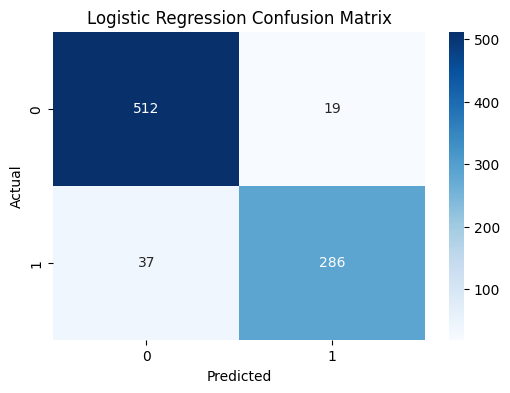

In [15]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
roc_lr = roc_auc_score(y_test, y_pred_lr)

print("ROC-AUC Score:", roc_lr)

ROC-AUC Score: 0.924833686076274


In [17]:
# Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.9953161592505855


In [18]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       531
           1       0.99      0.99      0.99       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



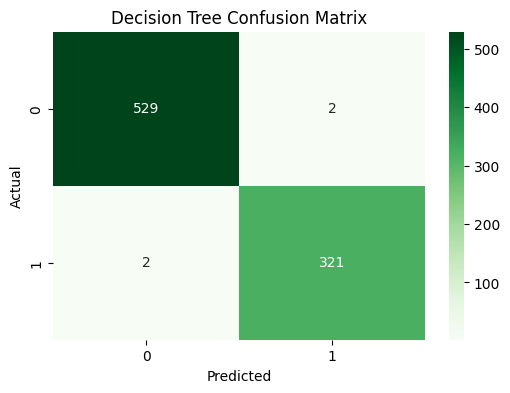

In [19]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
roc_dt = roc_auc_score(y_test, y_pred_dt)

print("Decision Tree ROC-AUC Score:", roc_dt)

Decision Tree ROC-AUC Score: 0.995020785596427


In [21]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9953161592505855


In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       531
           1       1.00      0.99      0.99       323

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854



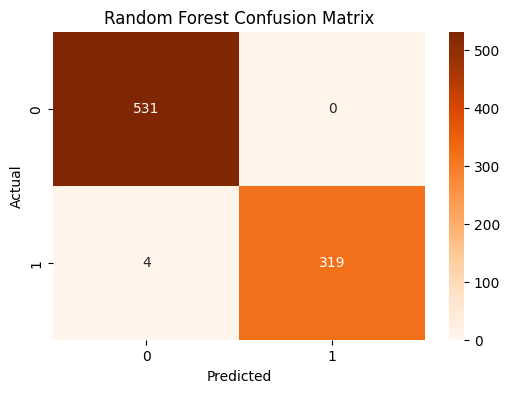

In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
roc_rf = roc_auc_score(y_test, y_pred_rf)

print("Random Forest ROC-AUC Score:", roc_rf)

Random Forest ROC-AUC Score: 0.9938080495356036


In [25]:
from xgboost import XGBClassifier

/home/deepakshevre/Desktop/DS_Notes/SEM 2/Mini Project/model_code/venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [26]:
# XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

/home/deepakshevre/Desktop/DS_Notes/SEM 2/Mini Project/model_code/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [12:13:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.9941451990632318


In [27]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       531
           1       1.00      0.99      0.99       323

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854



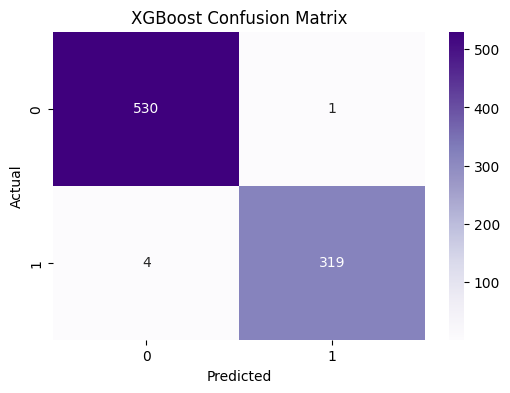

In [28]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
roc_xgb = roc_auc_score(y_test, y_pred_xgb)

print("XGBoost ROC-AUC Score:", roc_xgb)

XGBoost ROC-AUC Score: 0.9928664299499163


In [30]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "ROC-AUC": [
        roc_lr,
        roc_dt,
        roc_rf,
        roc_xgb
    ]
})

model_results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.934426,0.924834
1,Decision Tree,0.995316,0.995021
2,Random Forest,0.995316,0.993808
3,XGBoost,0.994145,0.992866


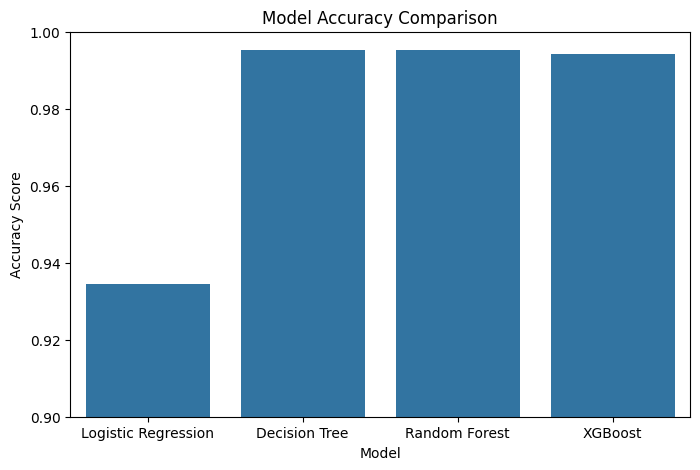

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=model_results
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0.9, 1.0)

plt.show()

In [32]:
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [33]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

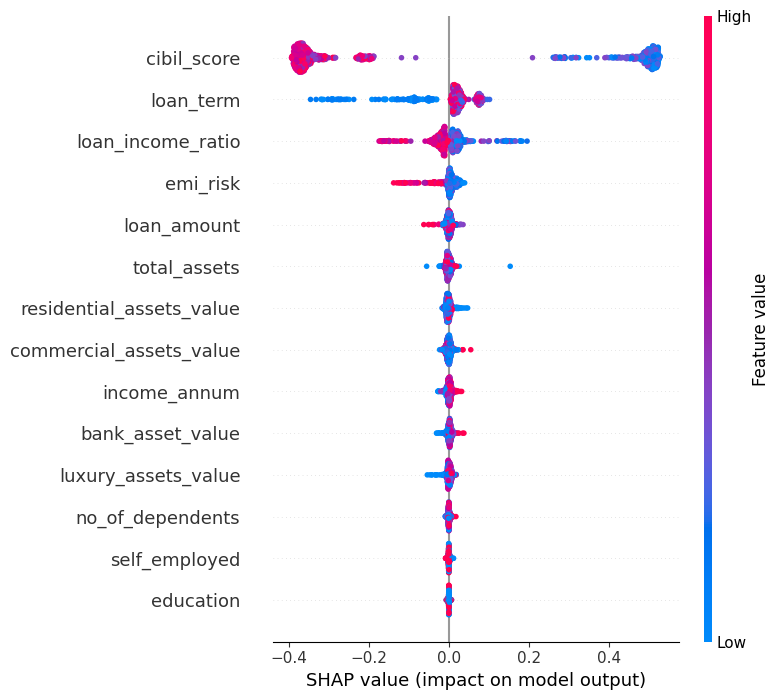

In [34]:
# Step 2 — Generate SHAP Summary Plot

feature_names = X.columns

shap.summary_plot(
    shap_values[1],
    X_test,
    feature_names=feature_names
)

In [35]:
# Step 3 — Calculate Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,cibil_score,0.783534
5,loan_term,0.050679
11,loan_income_ratio,0.042870
13,emi_risk,0.028717
4,loan_amount,0.015452
12,total_assets,0.012389
9,luxury_assets_value,0.011820
8,commercial_assets_value,0.011809
3,income_annum,0.011624
7,residential_assets_value,0.011486


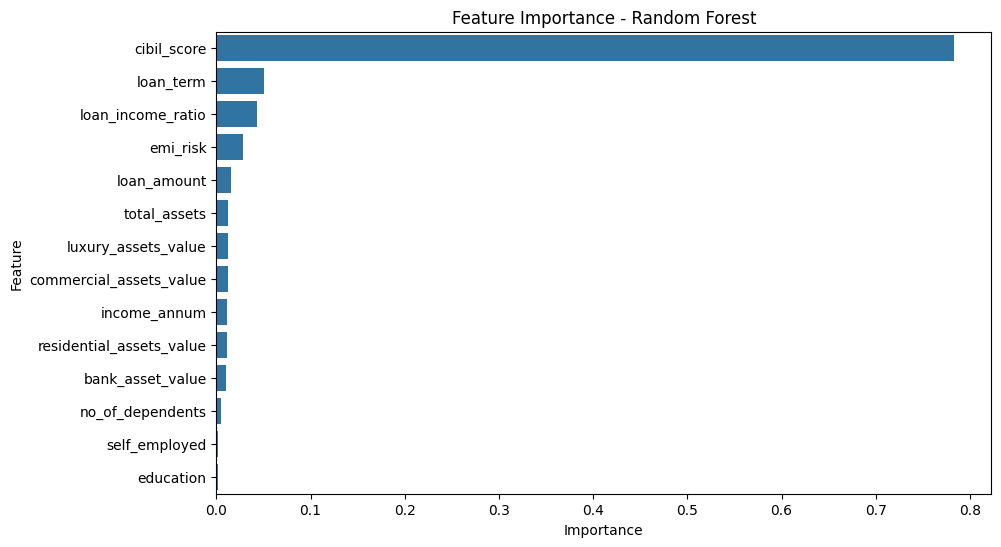

In [36]:
# Step 4 — Visualize Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

In [37]:
# Step 5 — Save Best Model

import joblib

joblib.dump(rf_model, "../models/best_model.pkl")

print("Best model saved successfully")

Best model saved successfully


In [38]:
# Step — Save StandardScaler

import joblib

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [39]:
print(df["loan_status"].value_counts())

loan_status
0    2656
1    1613
Name: count, dtype: int64


In [40]:
print(df[["loan_status"]].head(10))

   loan_status
0            0
1            1
2            1
3            1
4            1
5            1
6            0
7            1
8            0
9            1
